# Preparing Dataset for Fine-Tuning

In [2]:
# Imports:

import os
from dotenv import load_dotenv
from huggingface_hub import login
from pricer.items import Item
from tqdm.notebook import tqdm
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

In [3]:
# Log in to Hugging Face:
load_dotenv(override= True)
hf_token = os.getenv("HF_TOKEN")
login(token= hf_token, add_to_git_credential= True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## 1. Full Dataset

### Loading in Dataset

In [5]:
# Loading Full Version of Dataset from Hugging Face:
dataset_full = 'ed-donner/items_full'

train, val, test = Item.from_hub(dataset_name= dataset_full)
items = train + val + test
print(f'Loaded {len(train)} Training Items, {len(val)} Validation Items, {len(test)} Test Items.')

Loaded 800000 Training Items, 10000 Validation Items, 10000 Test Items.


### Base Model and Tokenizer:

In [6]:
BASE_MODEL = 'meta-llama/Llama-3.2-3B'
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

### Token Count in Full Dataset:

In [8]:
token_counts = [item.count_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/820000 [00:00<?, ?it/s]

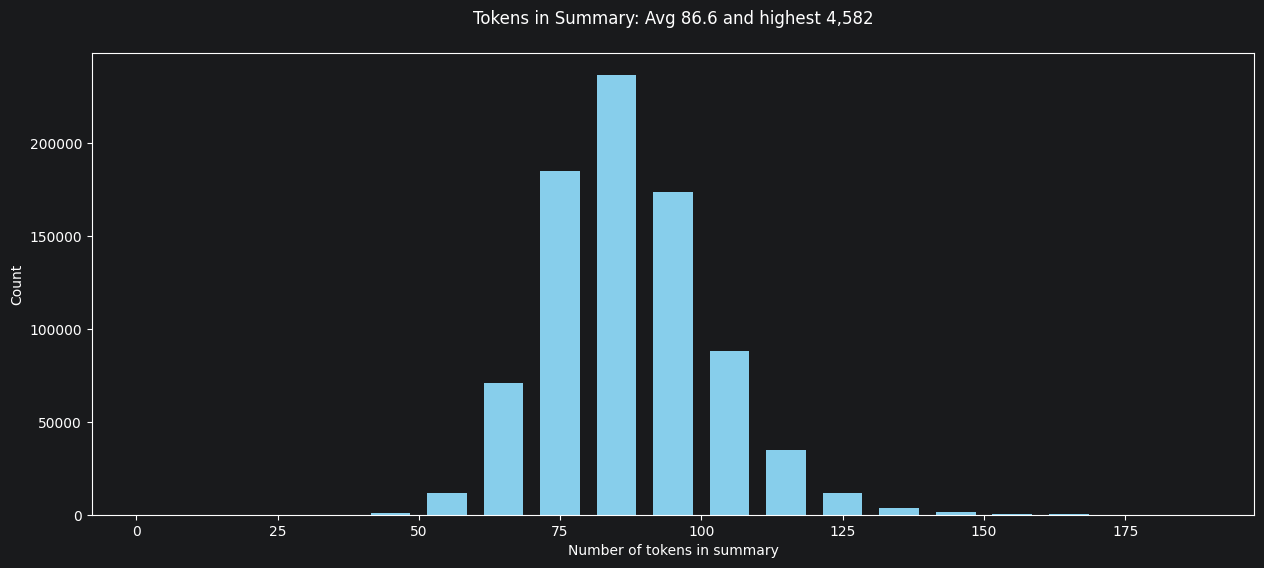

In [9]:
# Plotting Distribution for Number of Tokens:
plt.figure(figsize= (15, 6))
plt.title(f"Tokens in Summary: Avg {sum(token_counts)/len(token_counts):,.1f} and highest {max(token_counts):,}\n")
plt.xlabel('Number of tokens in summary')
plt.ylabel('Count')
plt.hist(token_counts, rwidth= 0.7, color= "skyblue", bins= range(0, 200, 10))
plt.show()

In [13]:
# Applying Cutoff to Number of Tokens:
CUTOFF = 110
cut = len([count for count in token_counts if count > CUTOFF])
print(f'With this CutOff, we will Truncate {cut} items, {cut / len(items):.1f}% of the total items.')

With this CutOff, we will Truncate 47083 items, 0.1% of the total items.


### Creating Fine Tuning Prompts for all Items:

In [14]:
# Making Fine-Tuning Prompts for all the Items of the Dataset:
for item in tqdm(train + val):
    item.make_prompts(tokenizer= tokenizer,
                      max_tokens= CUTOFF,
                      do_round= True)

for item in tqdm(test):
    item.make_prompts(tokenizer= tokenizer,
                      max_tokens= CUTOFF,
                      do_round= False)

  0%|          | 0/810000 [00:00<?, ?it/s]

  0%|          | 0/10000 [00:00<?, ?it/s]

In [15]:
print('PROMPT')
print(train[0].prompt)
print('COMPLETION')
print(train[0].completion)

PROMPT
What does this cost to the nearest dollar?

Title: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  
Category: Home Hardware  
Brand: Schlage  
Description: A single‑piece oil‑rubbed bronze knob that mounts to a deadbolt for secure, easy interior door use.  
Details: Designed for a 4" minimum center‑to‑center door prep, it offers a lifetime mechanical and finish warranty and comes ready for quick installation.

Price is $
COMPLETION
64.00


In [17]:
print('PROMPT')
print(test[1].prompt)
print('COMPLETION')
print(test[1].completion)

PROMPT
What does this cost to the nearest dollar?

Title: Telpo Headlight Assembly for 2015‑2017 Toyota Camry  
Category: Automotive Accessories  
Brand: Telpo  
Description: Dual headlight assembly that fits the 2015‑2017 Toyota Camry front driver and passenger sides.  
Details: Direct replacement with DOT & SAE‑certified lenses, high/low beam, waterproof construction, and a 1‑year limited warranty.

Price is $
COMPLETION
115.99


In [19]:
# Token Count in Dataset with Prompts and Completion:
prompt_token_counts = [item.count_prompt_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/820000 [00:00<?, ?it/s]

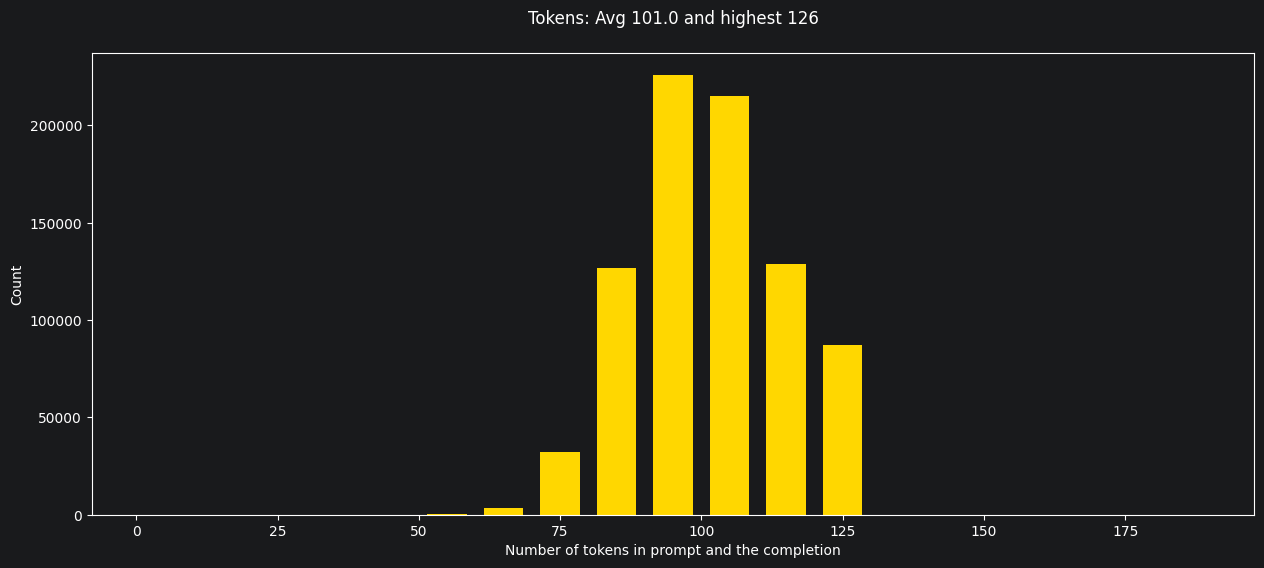

In [20]:
# Plotting Distribution for Number of Tokens in Prompt and Completions:

plt.figure(figsize=(15, 6))
plt.title(f"Tokens: Avg {sum(prompt_token_counts)/len(prompt_token_counts):,.1f} and highest {max(prompt_token_counts):,}\n")
plt.xlabel('Number of tokens in prompt and the completion')
plt.ylabel('Count')
plt.hist(prompt_token_counts, rwidth= 0.7, color= "gold", bins= range(0, 200, 10))
plt.show()

### Pushing Fine-Tuning Dataset to Hugging Face:

In [21]:
username = 'Shailya01'
dataset = f'{username}/items_prompt_full'

Item.push_prompts_to_hub(dataset_name= dataset,
                         train= train,
                         val= val,
                         test= test)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/800 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

New Data Upload: |          |  0.00B /  0.00B            

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/10 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

## 2. Lite Dataset:

### Loading in Dataset

In [4]:
# Loading Lite Version of Dataset from Hugging Face:
dataset_full = 'ed-donner/items_lite'

train, val, test = Item.from_hub(dataset_name= dataset_full)
items = train + val + test
print(f'Loaded {len(train)} Training Items, {len(val)} Validation Items, {len(test)} Test Items.')

Loaded 20000 Training Items, 1000 Validation Items, 1000 Test Items.


### Base Model and Tokenizer

In [5]:
BASE_MODEL = 'meta-llama/Llama-3.2-3B'
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

### Token Count in Lite Dataset

In [9]:
token_counts = [item.count_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/22000 [00:00<?, ?it/s]

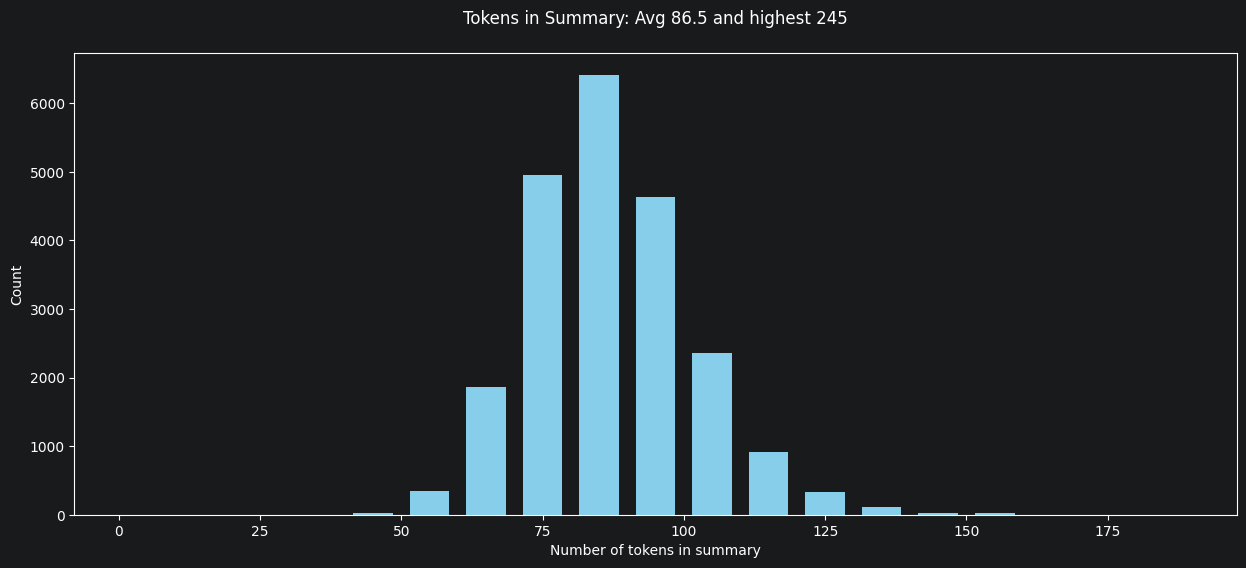

In [10]:
# Plotting Distribution for Number of Tokens:
plt.figure(figsize= (15, 6))
plt.title(f"Tokens in Summary: Avg {sum(token_counts)/len(token_counts):,.1f} and highest {max(token_counts):,}\n")
plt.xlabel('Number of tokens in summary')
plt.ylabel('Count')
plt.hist(token_counts, rwidth= 0.7, color= "skyblue", bins= range(0, 200, 10))
plt.show()

In [11]:
# Applying Cutoff to Number of Tokens:
CUTOFF = 110
cut = len([count for count in token_counts if count > CUTOFF])
print(f'With this CutOff, we will Truncate {cut} items, {cut / len(items):.1f}% of the total items.')

With this CutOff, we will Truncate 1255 items, 0.1% of the total items.


### Creating Fine Tuning Prompts for all Items:

In [12]:
# Making Fine-Tuning Prompts for all the Items of the Dataset:
for item in tqdm(train + val):
    item.make_prompts(tokenizer= tokenizer,
                      max_tokens= CUTOFF,
                      do_round= True)

for item in tqdm(test):
    item.make_prompts(tokenizer= tokenizer,
                      max_tokens= CUTOFF,
                      do_round= False)

  0%|          | 0/21000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

In [13]:
print('PROMPT:')
print(train[0].prompt)
print('COMPLETION:')
print(train[0].completion)

PROMPT:
What does this cost to the nearest dollar?

Title: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  
Category: Home Hardware  
Brand: Schlage  
Description: A single‑piece oil‑rubbed bronze knob that mounts to a deadbolt for secure, easy interior door use.  
Details: Designed for a 4" minimum center‑to‑center door prep, it offers a lifetime mechanical and finish warranty and comes ready for quick installation.

Price is $
COMPLETION:
64.00


In [15]:
print('PROMPT:')
print(test[5].prompt)
print('COMPLETION:')
print(test[5].completion)

PROMPT:
What does this cost to the nearest dollar?

Title: UPC RBC12-UPC Replacement Battery Cartridge  
Category: Electronics  
Brand: UPC  
Description: A precharged, maintenance‑free lead‑acid battery cartridge for APC RBC12 UPS systems that delivers reliable power during outages.  
Details: Sealed, leak‑proof design with all connectors, cable, and fuses included for instant plug‑and‑play, hot‑swappable installation, and a 2‑year limited warranty.

Price is $
COMPLETION:
229.99


In [16]:
# Token Count in Dataset with Prompts and Completion:
prompt_token_counts = [item.count_prompt_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/22000 [00:00<?, ?it/s]

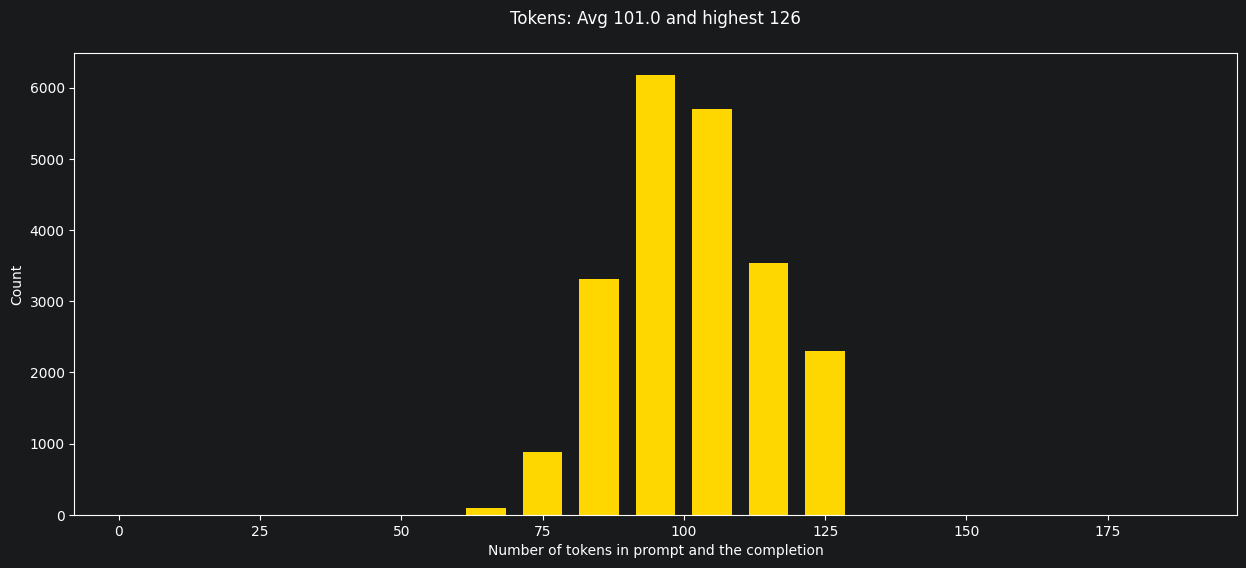

In [17]:
# Plotting Distribution for Number of Tokens in Prompt and Completions:

plt.figure(figsize=(15, 6))
plt.title(f"Tokens: Avg {sum(prompt_token_counts)/len(prompt_token_counts):,.1f} and highest {max(prompt_token_counts):,}\n")
plt.xlabel('Number of tokens in prompt and the completion')
plt.ylabel('Count')
plt.hist(prompt_token_counts, rwidth= 0.7, color= "gold", bins= range(0, 200, 10))
plt.show()

### Pushing Fine-Tuning Dataset (Lite Version) to Hugging Face:

In [18]:
username = 'Shailya01'
dataset = f'{username}/items_prompt_full'

Item.push_prompts_to_hub(dataset_name= dataset,
                         train= train,
                         val= val,
                         test= test)

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

Creating parquet from Arrow format:   0%|          | 0/20 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

README.md:   0%|          | 0.00/520 [00:00<?, ?B/s]

C:\Users\shail\anaconda3\envs\applied_llm_engineering\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\shail\.cache\huggingface\hub\datasets--Shailya01--items_prompt_full. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
